In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout , Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split

In [3]:
# Load the Fashion-MNIST dataset
df = pd.read_csv(r'D:\Deep Learning\Convolutional-Neural-Network(CNN)\PyTorch\MNIST_Fashion-data\fmnist_small.csv')
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(6000, 785)

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


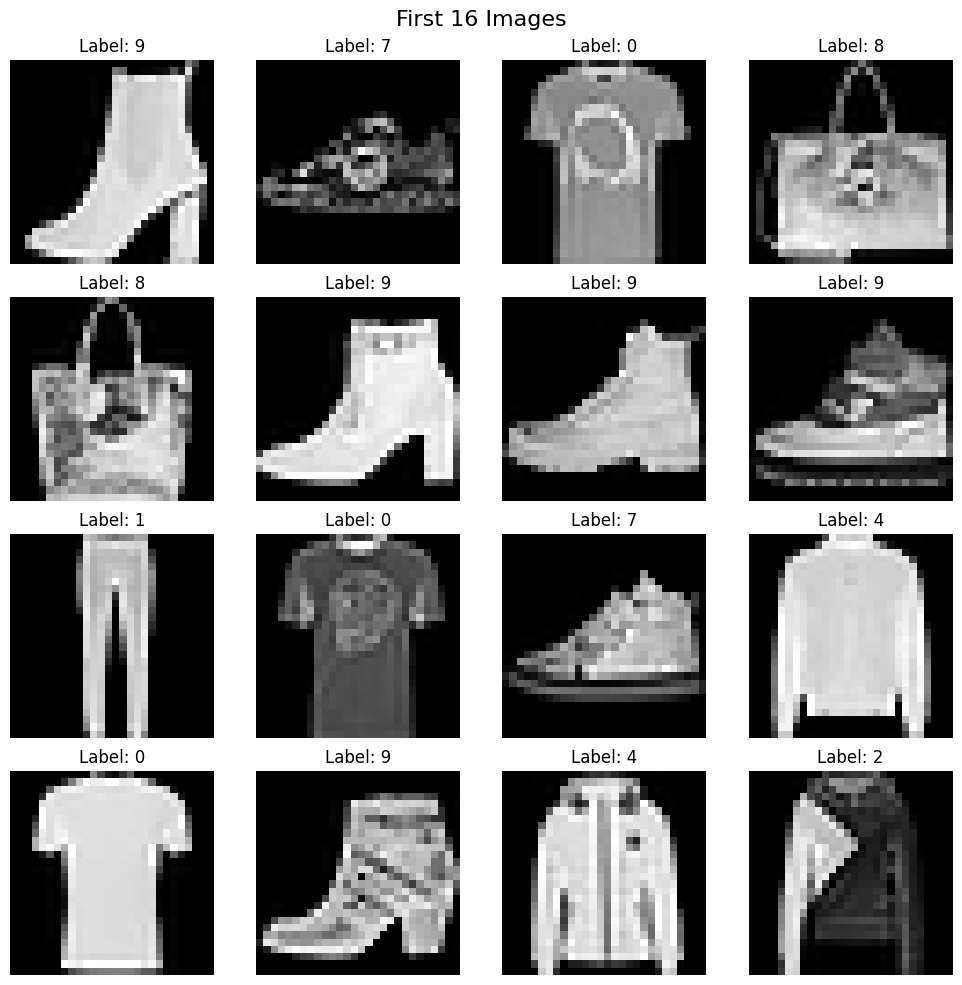

In [6]:
# create a 4x4 grid of images
fig,axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('First 16 Images', fontsize=16)

#plot the first 16 images from the dataset
for i , ax in enumerate(axes.flat):
    image = df.iloc[i, 1:].values.reshape(28, 28) # reshape the pixel values to 28x28
    ax.imshow(image, cmap='gray') # display the image in grayscale
    ax.set_title(f'Label: {df.iloc[i, 0]}') # set the title to the label of the image
    ax.axis('off') # turn off the axis

    plt.tight_layout() # adjust the layout to prevent overlap

In [7]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ..., 16,  0,  0]], shape=(4800, 784))

In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [11]:
X_train.shape

(4800, 784)

In [12]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [13]:
X_train.shape

(4800, 28, 28, 1)

In [14]:
model = Sequential()

model.add(Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(X_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5838 - loss: 1.1710 - val_accuracy: 0.7417 - val_loss: 0.6852
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7197 - loss: 0.7413 - val_accuracy: 0.7708 - val_loss: 0.6050
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7613 - loss: 0.6303 - val_accuracy: 0.7729 - val_loss: 0.5876
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7861 - loss: 0.5807 - val_accuracy: 0.7917 - val_loss: 0.5271
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8023 - loss: 0.5246 - val_accuracy: 0.8000 - val_loss: 0.4915
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8106 - loss: 0.4944 - val_accuracy: 0.8083 - val_loss: 0.4849
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8264 - loss: 0.4554 - val_accuracy: 0.8438 - val_loss: 0.4669
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8428 - loss: 0.4349 - val_accuracy: 0.

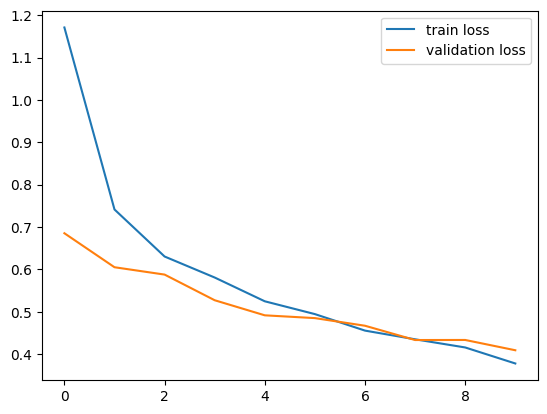

In [17]:
h = history

plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()